         Date    Open    High     Low   Close   Volume
0  2023-01-01  151.38  152.26  150.46  150.75  3715514
1  2023-01-02  149.81  150.69  148.29  150.54  1687409
2  2023-01-03  152.63  152.68  150.27  151.51  3658571
3  2023-01-04  152.67  155.72  152.47  153.79  1640053
4  2023-01-05  153.91  155.58  153.27  153.44  1860395


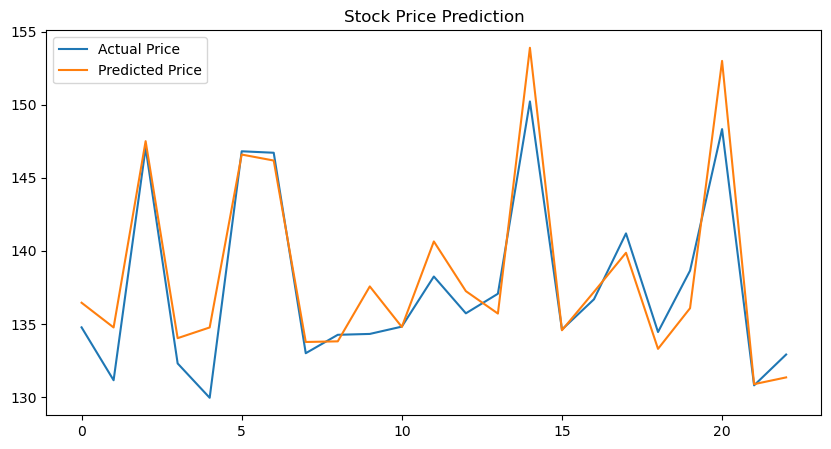

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

data = pd.read_csv("stock_price_data.csv")

print(data.head())

data = data[['Close']]

# Create prediction column (predict next 5 days)
data['Prediction'] = data['Close'].shift(-5)

X = np.array(data.drop(['Prediction'], axis=1))[:-5]
y = np.array(data['Prediction'])[:-5]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()